<a href="https://colab.research.google.com/github/sleepyarya/PCVK-SMT5/blob/main/Week7_AryaRamadhan_PCVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar (ganti 'sumber.jpg' sesuai nama file kamu)
img_gray = cv2.imread('sumber.jpg', cv2.IMREAD_GRAYSCALE)
img_bgr = cv2.imread('sumber.jpg')

# Jika gambar tidak ditemukan, otomatis buat gambar sintetis
if img_gray is None:
    img_gray = np.zeros((300, 300), dtype=np.uint8)
    cv2.rectangle(img_gray, (50, 50), (250, 250), 255, -1)
    cv2.circle(img_gray, (150, 150), 50, 0, -1)
    img_bgr = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

PERCOBAAN 1: Filter Dasar dengan Konvolusi Manual

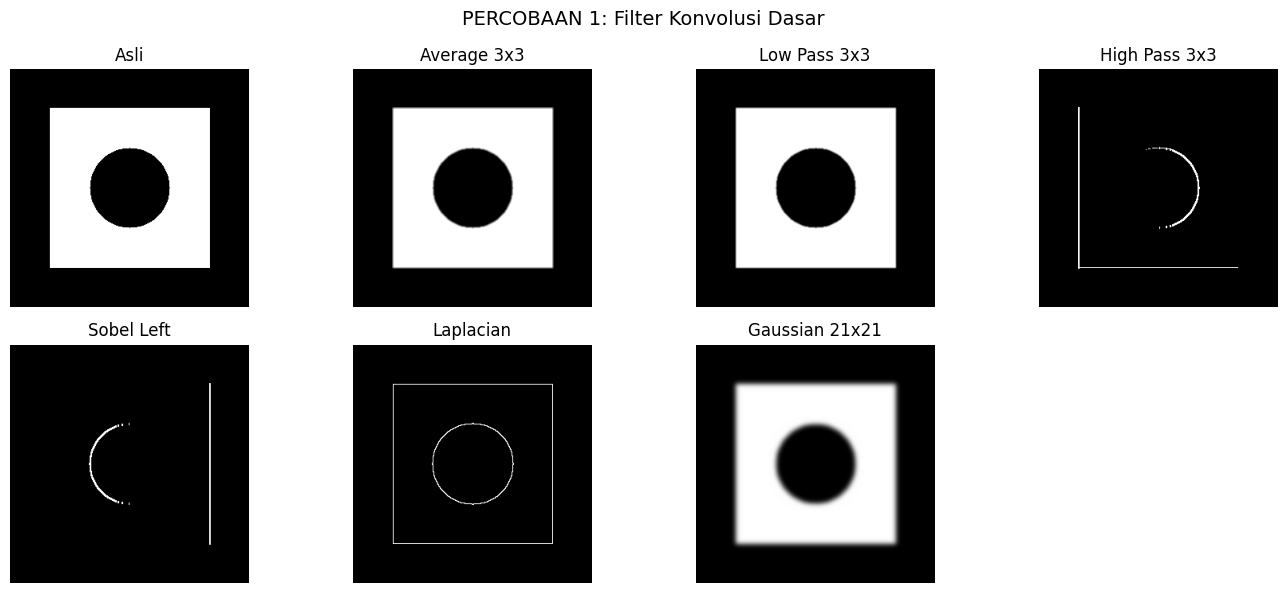

In [6]:
# Fungsi konvolusi manual
def manual_convolve(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

# Matriks Kernel Percobaan 1
kernel_avg = np.ones((3, 3), np.float32) / 9.0
kernel_lpf = np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], dtype=np.float32) / 12.0
kernel_hpf = np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]], dtype=np.float32)
kernel_sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
kernel_laplacian = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)

g1d = cv2.getGaussianKernel(21, 3)
kernel_gaussian21 = g1d @ g1d.T

# Eksekusi Filter
p1_avg = manual_convolve(img_gray, kernel_avg)
p1_lpf = manual_convolve(img_gray, kernel_lpf)
p1_hpf = manual_convolve(img_gray, kernel_hpf)
p1_sobel = manual_convolve(img_gray, kernel_sobel)
p1_laplacian = manual_convolve(img_gray, kernel_laplacian)
p1_gaussian = manual_convolve(img_gray, kernel_gaussian21)

# Plot Percobaan 1
imgs_p1 = [img_gray, p1_avg, p1_lpf, p1_hpf, p1_sobel, p1_laplacian, p1_gaussian]
titles_p1 = ['Asli', 'Average 3x3', 'Low Pass 3x3', 'High Pass 3x3', 'Sobel Left', 'Laplacian', 'Gaussian 21x21']

plt.figure(figsize=(14, 6))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.imshow(imgs_p1[i], cmap='gray')
    plt.title(titles_p1[i])
    plt.axis('off')
plt.suptitle('PERCOBAAN 1: Filter Konvolusi Dasar', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 2: Bilateral Filter & Guided Filter

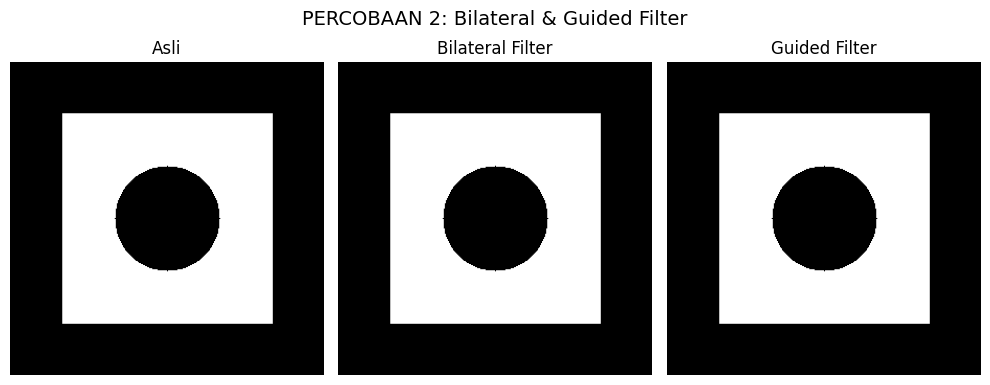

In [7]:
# Bilateral Filter
p2_bilateral = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

# Guided Filter
try:
    p2_guided = cv2.ximgproc.guidedFilter(guide=img_rgb, src=img_rgb, radius=8, eps=50)
except AttributeError:
    p2_guided = cv2.edgePreservingFilter(img_rgb, flags=1, sigma_s=60, sigma_r=0.4)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(p2_bilateral); plt.title('Bilateral Filter'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(p2_guided); plt.title('Guided Filter'); plt.axis('off')
plt.suptitle('PERCOBAAN 2: Bilateral & Guided Filter', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 3: Visualisasi Feature Map CNN

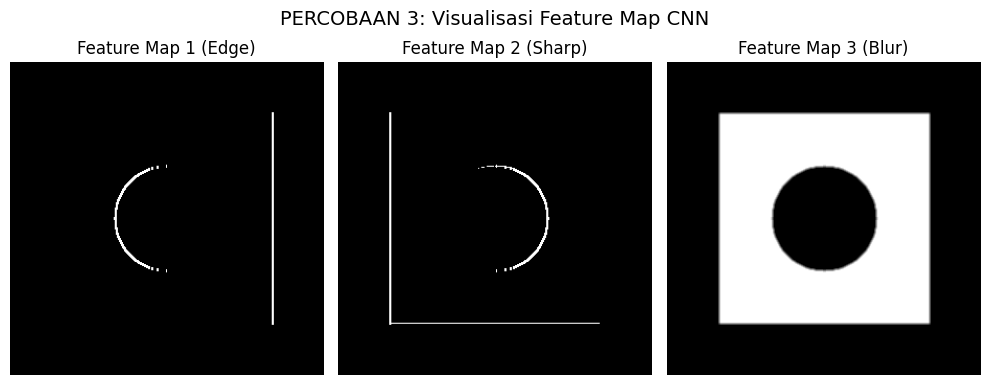

In [8]:
# Simulasi Feature Map layer CNN menggunakan beberapa filter berbeda
p3_feat_edge = cv2.filter2D(img_gray, -1, kernel_sobel)
p3_feat_sharp = cv2.filter2D(img_gray, -1, kernel_hpf)
p3_feat_blur = cv2.filter2D(img_gray, -1, kernel_avg)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(p3_feat_edge, cmap='gray'); plt.title('Feature Map 1 (Edge)'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(p3_feat_sharp, cmap='gray'); plt.title('Feature Map 2 (Sharp)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(p3_feat_blur, cmap='gray'); plt.title('Feature Map 3 (Blur)'); plt.axis('off')
plt.suptitle('PERCOBAAN 3: Visualisasi Feature Map CNN', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 4: Filter Kombinasi Beauty & Vintage

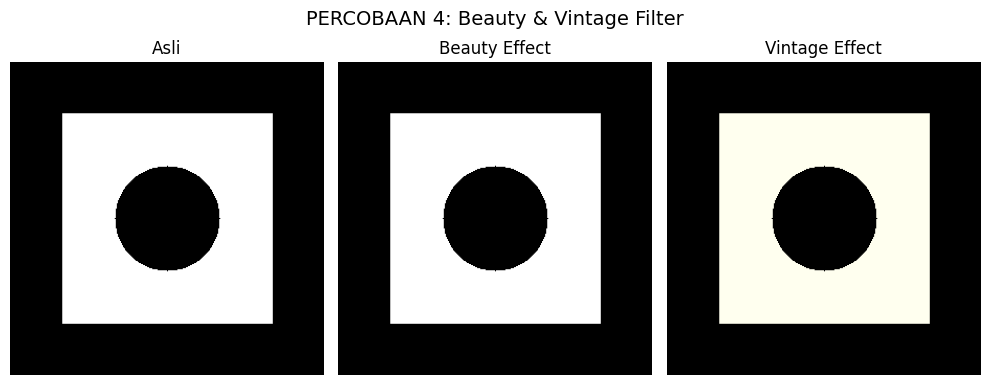

In [9]:
# Beauty Filter
def beauty_filter(img):
    smoothed = cv2.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
    sharpen_k = np.array([[0, -0.5, 0], [-0.5, 3, -0.5], [0, -0.5, 0]], dtype=np.float32)
    enhanced = cv2.filter2D(smoothed, -1, sharpen_k)
    return cv2.addWeighted(img, 0.3, enhanced, 0.7, 0)

# Vintage Filter
def vintage_filter(img):
    kernel_vintage = np.array([[0.393, 0.769, 0.189], [0.349, 0.686, 0.168], [0.272, 0.534, 0.131]])
    return np.clip(cv2.transform(img, kernel_vintage), 0, 255).astype(np.uint8)

p4_beauty = beauty_filter(img_rgb)
p4_vintage = vintage_filter(img_rgb)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(p4_beauty); plt.title('Beauty Effect'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(p4_vintage); plt.title('Vintage Effect'); plt.axis('off')
plt.suptitle('PERCOBAAN 4: Beauty & Vintage Filter', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 5: Filter Anime / Cartoon Sederhana

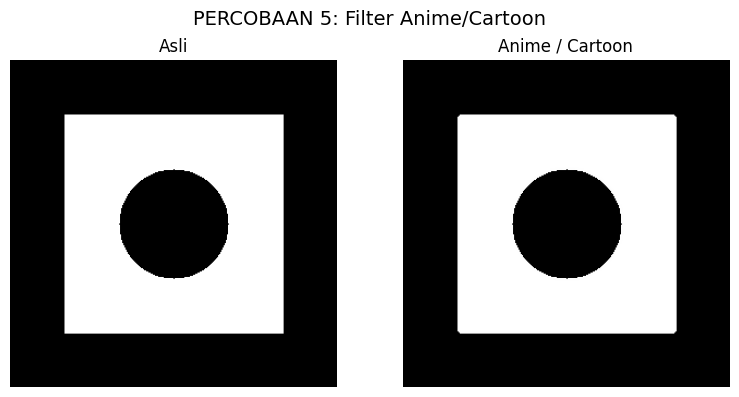

In [10]:
def anime_filter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.medianBlur(gray, 5)
    edges = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 9)
    color = cv2.bilateralFilter(img, 9, 250, 250)
    return cv2.bitwise_and(color, color, mask=edges)

p5_anime = anime_filter(img_rgb)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(p5_anime); plt.title('Anime / Cartoon'); plt.axis('off')
plt.suptitle('PERCOBAAN 5: Filter Anime/Cartoon', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 6: Filter Suasana (Filter Malam)

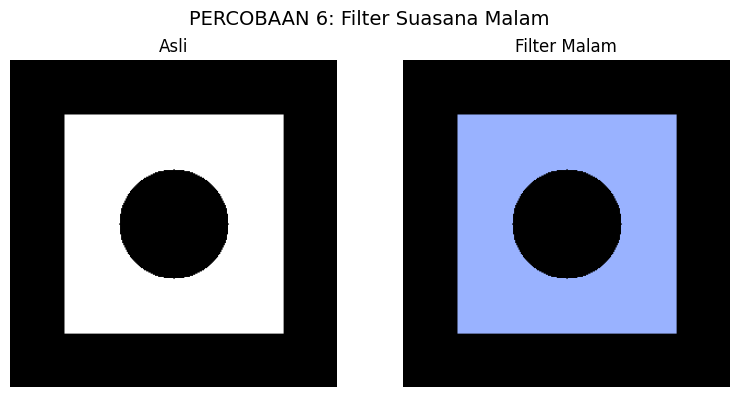

In [11]:
def night_filter(img):
    night = img.astype(np.float32)
    night[:, :, 0] *= 0.6  # Red dikurangi
    night[:, :, 1] *= 0.7  # Green dikurangi
    night[:, :, 2] *= 1.2  # Blue dinaikkan
    return np.clip(night, 0, 255).astype(np.uint8)

p6_night = night_filter(img_rgb)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(p6_night); plt.title('Filter Malam'); plt.axis('off')
plt.suptitle('PERCOBAAN 6: Filter Suasana Malam', fontsize=14)
plt.tight_layout()
plt.show()

PERCOBAAN 7: Filter Suasana (Pagi & Efek Kabut)

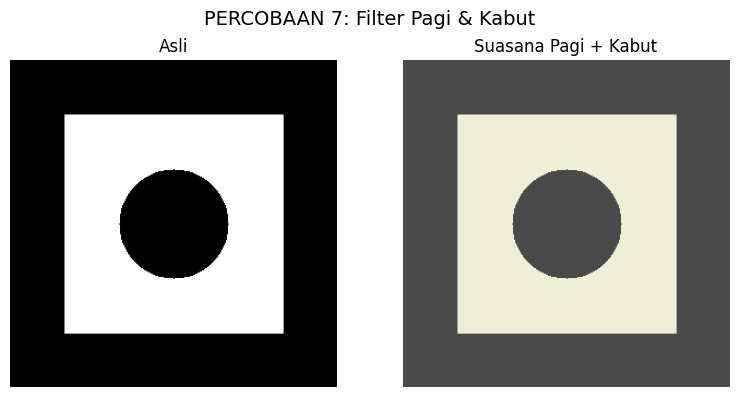

In [12]:
def morning_fog_filter(img):
    morning = img.astype(np.float32)
    morning[:, :, 0] *= 1.15 # Warm tone (Red)
    morning[:, :, 1] *= 1.05
    morning[:, :, 2] *= 0.85
    morning = np.clip(morning, 0, 255).astype(np.uint8)

    # Tambah efek kabut
    fog_layer = np.full_like(img, 210, dtype=np.uint8)
    return cv2.addWeighted(morning, 0.65, fog_layer, 0.35, 0)

p7_fog = morning_fog_filter(img_rgb)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(p7_fog); plt.title('Suasana Pagi + Kabut'); plt.axis('off')
plt.suptitle('PERCOBAAN 7: Filter Pagi & Kabut', fontsize=14)
plt.tight_layout()
plt.show()

TUGAS PRAKTIKUM

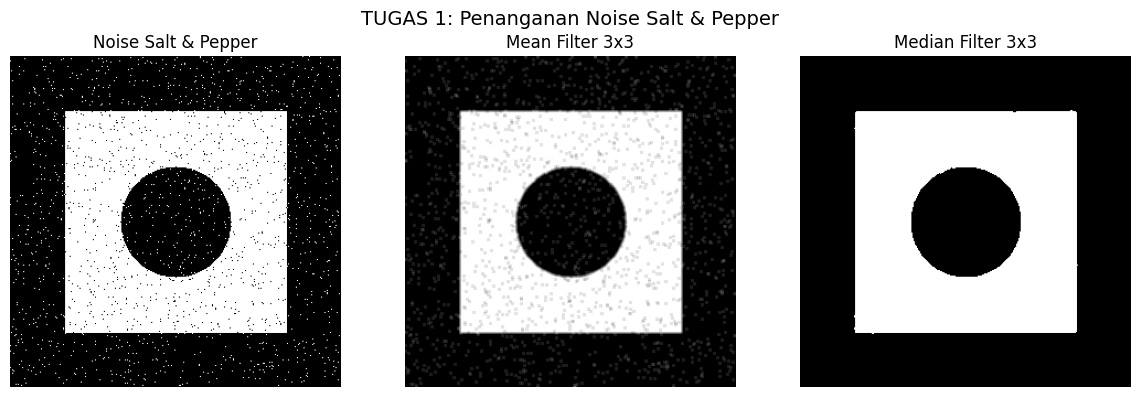

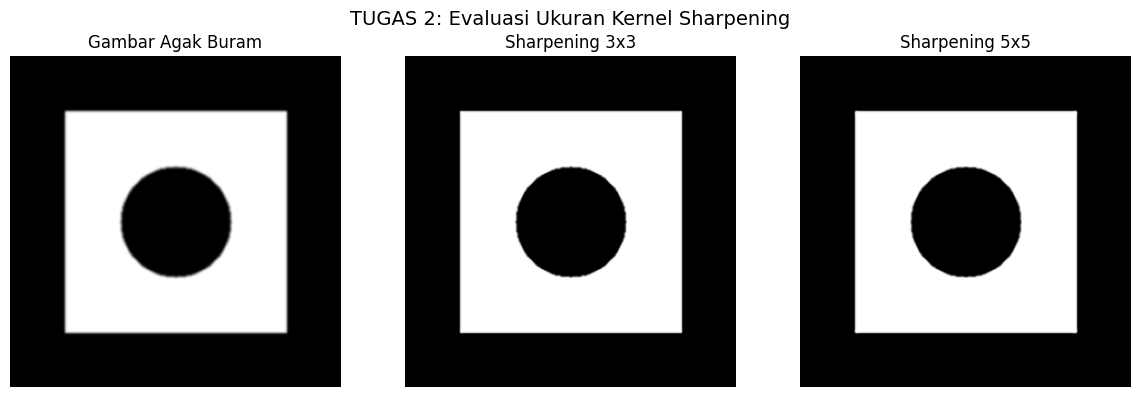

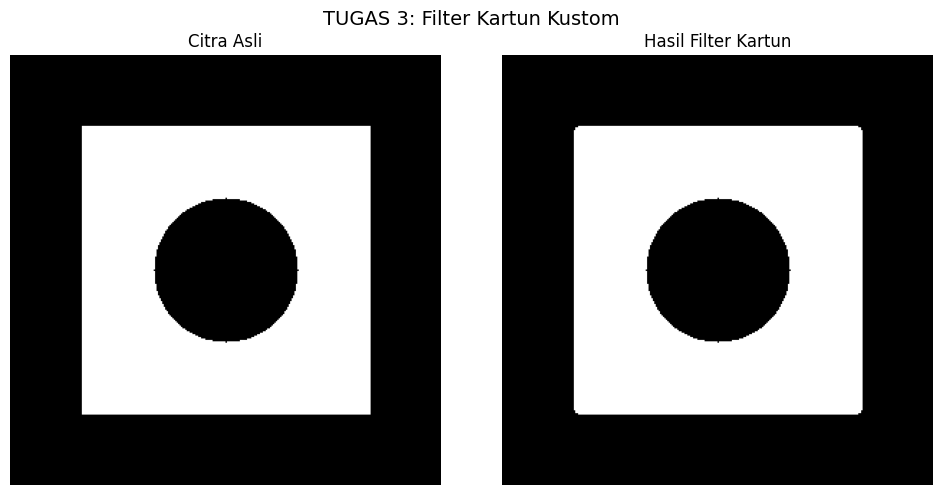

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# TUGAS 1: Mean Filter vs Median Filter pada Noise Salt & Pepper
# ==========================================
def add_salt_and_pepper(image):
    noisy = image.copy()
    # Salt noise (bintik putih)
    num_salt = int(0.02 * image.size)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[tuple(coords)] = 255
    # Pepper noise (bintik hitam)
    num_pepper = int(0.02 * image.size)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

noisy_img = add_salt_and_pepper(img_gray)
t1_mean = cv2.blur(noisy_img, (3, 3))
t1_median = cv2.medianBlur(noisy_img, 3)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(noisy_img, cmap='gray'); plt.title('Noise Salt & Pepper'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(t1_mean, cmap='gray'); plt.title('Mean Filter 3x3'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(t1_median, cmap='gray'); plt.title('Median Filter 3x3'); plt.axis('off')
plt.suptitle('TUGAS 1: Penanganan Noise Salt & Pepper', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# TUGAS 2: Ukuran Kernel Sharpening (3x3 vs 5x5)
# ==========================================
blurred_img = cv2.GaussianBlur(img_gray, (5, 5), 0)

k_sharp_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

k_sharp_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  8,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1]
], dtype=np.float32) / 8.0

t2_sharp3x3 = cv2.filter2D(blurred_img, -1, k_sharp_3x3)
t2_sharp5x5 = cv2.filter2D(blurred_img, -1, k_sharp_5x5)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(blurred_img, cmap='gray'); plt.title('Gambar Agak Buram'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(t2_sharp3x3, cmap='gray'); plt.title('Sharpening 3x3'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(t2_sharp5x5, cmap='gray'); plt.title('Sharpening 5x5'); plt.axis('off')
plt.suptitle('TUGAS 2: Evaluasi Ukuran Kernel Sharpening', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# TUGAS 3: Kreasi Filter Kartun Kustom
# ==========================================
def kartun(image_rgb):
    # 1. Penghalusan warna dengan Bilateral Filter
    color = cv2.bilateralFilter(image_rgb, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.medianBlur(gray, 7)
    edges = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 9)

    # 3. Penggabungan warna dan tepi menggunakan perkalian mask
    cartoon_img = cv2.bitwise_and(color, color, mask=edges)
    return cartoon_img

t3_kartun = kartun(img_rgb)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Citra Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(t3_kartun); plt.title('Hasil Filter Kartun'); plt.axis('off')
plt.suptitle('TUGAS 3: Filter Kartun Kustom', fontsize=14)
plt.tight_layout()
plt.show()

Mengapa Median Filter jauh lebih baik?

Noise Salt & Pepper merupakan nilai piksel ekstrem ($0$ untuk hitam murni atau $255$ untuk putih murni). Median Filter mengurutkan nilai piksel tetangga dan mengambil nilai tengahnya (median). Karena nilai ekstrem berada di posisi paling ujung saat diurutkan, bintik noise terhapus sepenuhnya tanpa mengaburkan detail citra. Sebaliknya, Mean Filter menghitung rata-rata, sehingga nilai ekstrem $0$ dan $255$ ikut terhitung dan menghasilkan noda buram pada citra.

Kejelasan Tepi vs. Kadar Noise:

Kernel $3 \times 3$ memberikan peningkatan ketajaman yang pas pada garis tepi tanpa memunculkan distorsi. Sedangkan kernel $5 \times 5$ terlalu agresif sehingga menghasilkan efek over-sharpening (garis tepi terlihat terlalu tebal/buatan) serta mempertegas noise pada area citra yang seharusnya mulus.

Ukuran Optimal:

Kernel $3 \times 3$ adalah ukuran yang paling optimal untuk penajaman citra standar.